<>:26: SyntaxWarning: invalid escape sequence '\z'
<>:27: SyntaxWarning: invalid escape sequence '\z'
<>:28: SyntaxWarning: invalid escape sequence '\z'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\z'
<>:27: SyntaxWarning: invalid escape sequence '\z'
<>:28: SyntaxWarning: invalid escape sequence '\z'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:120: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2090/3661847367.py:26: SyntaxWarning: invalid escape sequence '\z'
  plt.plot(sol_under.t, sol_under.y[0], label='Slabé tlumení ($\zeta=0.1$)')
/tmp/ipykernel_2090/3661847367.py:27: SyntaxWarning: invalid escape sequence '\z'
  plt.plot(sol_crit.t, sol_crit.y[0], label='Kritické tlumení ($\zeta=1.0$)')
/tmp/ipykernel_2090/3661847367.py:28: SyntaxWarning: invalid escape sequence '\z'
  plt.plot(sol_over.t, sol_over.y[0], label='Silné tlumení ($\zeta=2.0$)')
/tmp/ipyke

Simulace Části A: Lineární oscilátor...


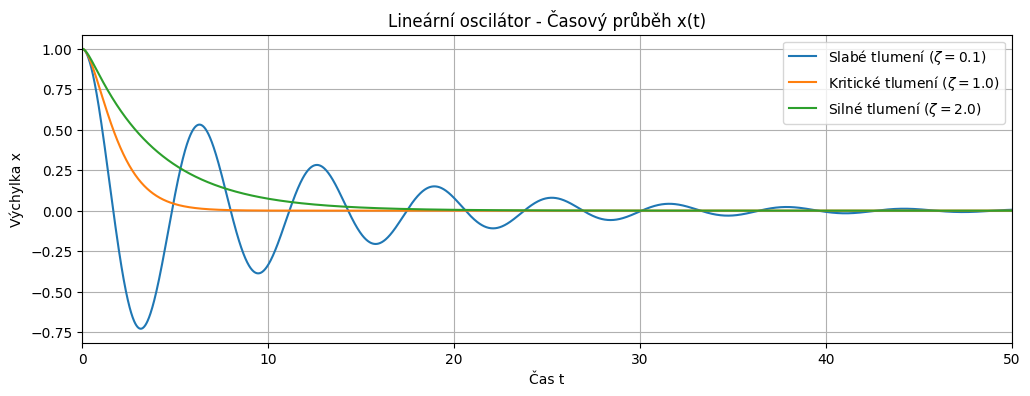


Simulace Části B: Duffingův oscilátor...


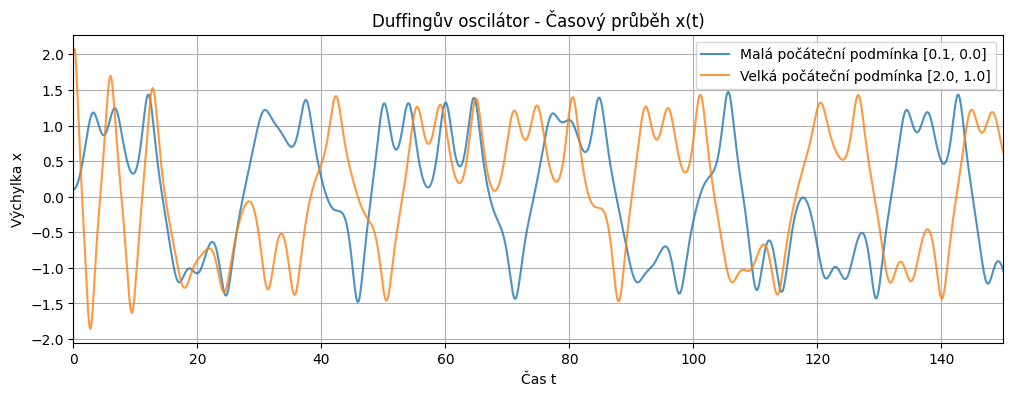

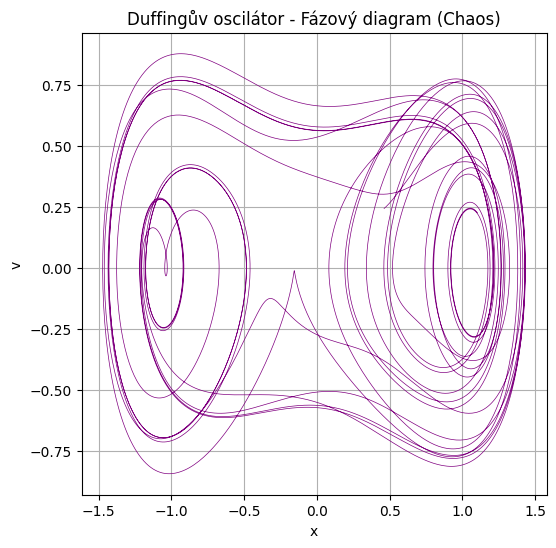

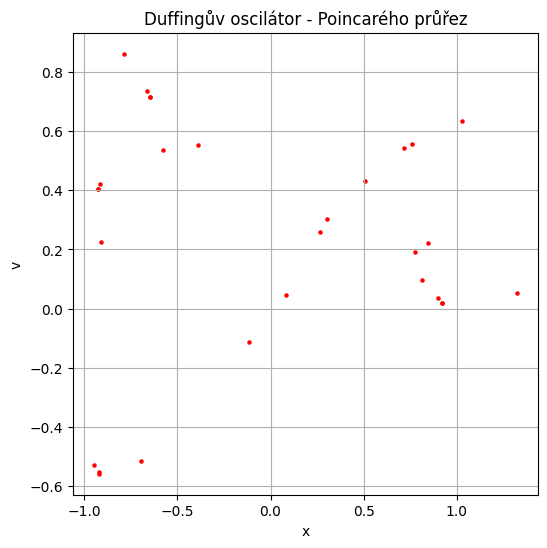


Simulace Části C: Van der Polův oscilátor...


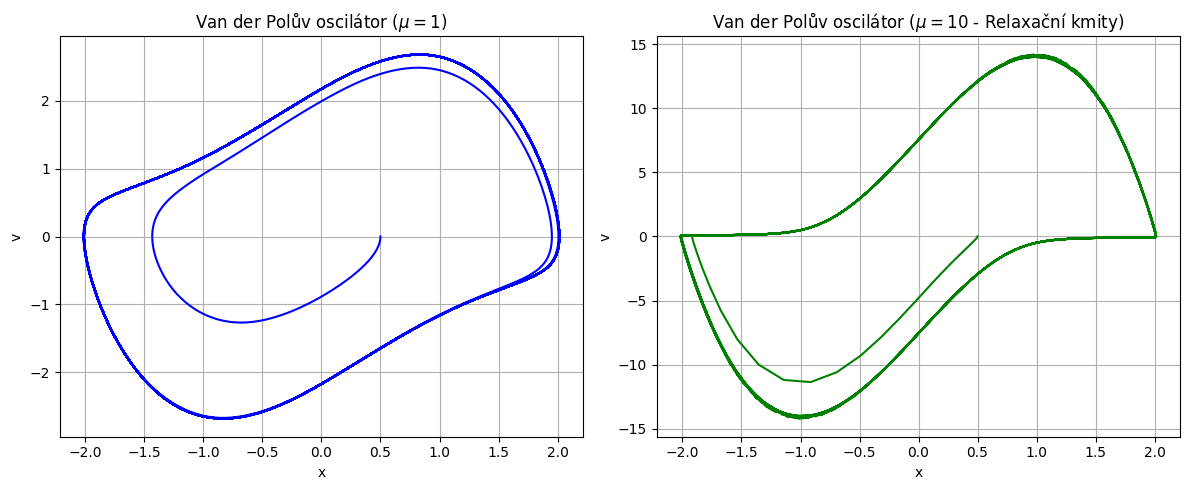

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Společné nastavení času pro simulace (delší interval pro projevení chaosu/cyklů)
t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# =============================================================================
# ČÁST A: Lineární tlumený oscilátor
# =============================================================================
print("Simulace Části A: Lineární oscilátor...")

def linear_oscillator(t, y, zeta, omega_n):
    x, v = y
    return [v, -2 * zeta * omega_n * v - omega_n**2 * x]

omega_n = 1.0
y0_linear = [1.0, 0.0] # Počáteční podmínka

sol_under = solve_ivp(linear_oscillator, t_span, y0_linear, t_eval=t_eval, args=(0.1, omega_n))
sol_crit = solve_ivp(linear_oscillator, t_span, y0_linear, t_eval=t_eval, args=(1.0, omega_n))
sol_over = solve_ivp(linear_oscillator, t_span, y0_linear, t_eval=t_eval, args=(2.0, omega_n))

plt.figure(figsize=(12, 4))
plt.plot(sol_under.t, sol_under.y[0], label='Slabé tlumení ($\zeta=0.1$)')
plt.plot(sol_crit.t, sol_crit.y[0], label='Kritické tlumení ($\zeta=1.0$)')
plt.plot(sol_over.t, sol_over.y[0], label='Silné tlumení ($\zeta=2.0$)')
plt.title('Lineární oscilátor - Časový průběh x(t)')
plt.xlabel('Čas t')
plt.ylabel('Výchylka x')
plt.xlim(0, 50)
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# ČÁST B: Duffingův oscilátor (Nelineární - chaotický režim)
# =============================================================================
print("\nSimulace Části B: Duffingův oscilátor...")

def duffing_oscillator(t, y, delta, alpha, beta, gamma, omega):
    x, v = y
    return [v, -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)]

# Doporučené parametry ze zadání
delta = 0.2
alpha = -1.0
beta = 1.0
gamma = 0.3
omega = 1.2

# Simulace pro dvě různé počáteční podmínky (malá vs. velká)
y0_duff_small = [0.1, 0.0]
y0_duff_large = [2.0, 1.0]

sol_duff_small = solve_ivp(duffing_oscillator, t_span, y0_duff_small, t_eval=t_eval, args=(delta, alpha, beta, gamma, omega))
sol_duff_large = solve_ivp(duffing_oscillator, t_span, y0_duff_large, t_eval=t_eval, args=(delta, alpha, beta, gamma, omega))

# 1. Časový průběh x(t)
plt.figure(figsize=(12, 4))
plt.plot(sol_duff_small.t, sol_duff_small.y[0], label='Malá počáteční podmínka [0.1, 0.0]', alpha=0.8)
plt.plot(sol_duff_large.t, sol_duff_large.y[0], label='Velká počáteční podmínka [2.0, 1.0]', alpha=0.8)
plt.title('Duffingův oscilátor - Časový průběh x(t)')
plt.xlabel('Čas t')
plt.ylabel('Výchylka x')
plt.xlim(0, 150)
plt.legend()
plt.grid(True)
plt.show()

# 2. Fázový diagram (x vs v) pro velkou počáteční podmínku (po odeznění přechodového děje)
plt.figure(figsize=(6, 6))
plt.plot(sol_duff_large.y[0][2000:], sol_duff_large.y[1][2000:], color='purple', lw=0.5)
plt.title('Duffingův oscilátor - Fázový diagram (Chaos)')
plt.xlabel('x')
plt.ylabel('v')
plt.grid(True)
plt.show()

# 3. Poincarého průřez (vzorkování v čase t = n * T, kde T = 2*pi/omega)
T = 2 * np.pi / omega
t_poincare = np.arange(0, t_span[1], T)
sol_poincare = solve_ivp(duffing_oscillator, t_span, y0_duff_large, t_eval=t_poincare, args=(delta, alpha, beta, gamma, omega))

plt.figure(figsize=(6, 6))
plt.scatter(sol_poincare.y[0][10:], sol_poincare.y[1][10:], color='red', s=5, marker='o')
plt.title('Duffingův oscilátor - Poincarého průřez')
plt.xlabel('x')
plt.ylabel('v')
plt.grid(True)
plt.show()

# =============================================================================
# ČÁST C: Van der Polův oscilátor (Nelineární - limitní cykly)
# =============================================================================
print("\nSimulace Části C: Van der Polův oscilátor...")

def vdp_oscillator(t, y, mu):
    x, v = y
    return [v, mu * (1 - x**2) * v - x]

y0_vdp = [0.5, 0.0]

sol_vdp_1 = solve_ivp(vdp_oscillator, t_span, y0_vdp, t_eval=t_eval, args=(1.0,))
sol_vdp_10 = solve_ivp(vdp_oscillator, t_span, y0_vdp, t_eval=t_eval, args=(10.0,))

# Fázové diagramy pro mu=1 a mu=10
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sol_vdp_1.y[0], sol_vdp_1.y[1], color='blue')
plt.title('Van der Polův oscilátor ($\mu = 1$)')
plt.xlabel('x')
plt.ylabel('v')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(sol_vdp_10.y[0], sol_vdp_10.y[1], color='green')
plt.title('Van der Polův oscilátor ($\mu = 10$ - Relaxační kmity)')
plt.xlabel('x')
plt.ylabel('v')
plt.grid(True)

plt.tight_layout()
plt.show()

Odpovědi na zadané otázky:
**A) Odpovědi k lineárnímu oscilátoru:**
* **Rozdíly tlumení:** Slabé tlumení (underdamped) způsobuje, že systém kmitá kolem rovnovážné polohy se zmenšující se amplitudou. Kritické tlumení (critical) zajišťuje nejrychlejší možný návrat do rovnovážné polohy bez překmitu. Silné tlumení (overdamped) systém výrazně brzdí a návrat do rovnováhy trvá velmi dlouho.
* **Změna parametrů:** Pokud změníme tlumení o několik procent v rámci jednoho režimu, chování se mění plynule (např. kmitá nepatrně déle). Přechod přes kritickou hranici (např. ze slabého do kritického/silného) je však kvalitativně ostrý – oscilace zcela mizí.
* **Rezonance:** K rezonanci dochází, pokud se frekvence vnější budící síly ($\gamma \cos(\omega t)$) vyrovná vlastní úhlové frekvenci systému.
* **Symbolická matematika:** Ano, problém se dá řešit analyticky. V Pythonu lze k nalezení explicitního řešení diferenciální rovnice využít knihovnu `sympy` a její funkci `dsolve`.

**B) Odpovědi k Duffingovu oscilátoru:**
* **Chaotické chování:** Ano, pro doporučené parametry ($\delta=0.2$, $\alpha=-1$, $\beta=1$, $\gamma=0.3$, $\omega=1.2$) systém vykazuje chaotické chování, což je zřetelně vidět na fraktální struktuře Poincarého průřezu.
* **Počáteční podmínky:** U malé počáteční podmínky systém často nejprve "uvízne" v jedné z potenciálových studní (kmitá lokálně), než se vyvine plný chaos. Velká počáteční podmínka dodá hned na začátku tolik energie, že systém okamžitě přeskakuje mezi oběma studnami a ihned ukazuje plně chaotickou trajektorii.
* **Zvýšení buzení $\gamma$:** Pokud budeme postupně zvyšovat amplitudu buzení, systém bude procházet tzv. bifurkacemi. Chaotický atraktor se může zhroutit do jednoduchého periodického cyklu o velké amplitudě (stabilní okna v chaosu), nebo se může objevit koexistence více atraktorů.

**C) Odpovědi k Van der Polovu oscilátoru:**
* **Změna tvaru:** Při $\mu=1$ má limitní cyklus tvar mírně deformované elipsy (téměř harmonický průběh). Při $\mu=10$ (silná nelinearita) se radikálně mění a vznikají tzv. relaxační kmity.
* **Rychlé skoky a pomalé fáze:** Vznikají kvůli nelineárnímu tlumícímu členu $\mu(1-x^2)\dot{x}$. Pro malá $|x|$ systém energii nabírá (pomalá akumulační fáze), ale jakmile výchylka překročí určitou mez, znaménko tlumení se otočí a systém energii prudce ztrácí, což vyvolá okamžitý skok (překlopení na druhou stranu).
* **Vliv počátečních podmínek:** Počáteční podmínky ovlivní pouze trajektorii a čas, než se systém dostane na ustálenou dráhu. Na konečné chování nemají vliv.
* **Více atraktorů:** Ne. V tomto konkrétním modelu existuje pouze jediný globálně stabilní limitní cyklus (atraktor), ke kterému nakonec zkonvergují všechny trajektorie (kromě počátku, který je nestabilním bodem).